In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import opendatasets as od 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pandas as pd
import os

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import random
from PIL import Image
import cv2

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout



In [2]:
# od.download(
#     "https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k")

data = pd.read_excel("./Multi Class Preprocessed.xlsx")

path_to_images = "./ocular-disease-recognition-odir5k/"
data.head()

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
3,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
4,5,50,Female,5_left.jpg,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0


In [3]:
normal_fundus = data[data['N'] == 1].iloc[:, :450]
normal_fundus.drop(normal_fundus.index[450:], inplace=True)
diabetes = data[data['D'] == 1].iloc[:, :450]
diabetes.drop(diabetes.index[250:], inplace=True)
glaucoma = data[data['G'] == 1].iloc[:, :217]
cataract = data[data['C'] == 1].iloc[:, :250]
armd = data[data['A'] == 1].iloc[:, :236]
hypertension = data[data['H'] == 1].iloc[:, :103]
myopia = data[data['M'] == 1].iloc[:, :238]
others = data[data['O'] == 1].iloc[:, :450]
others.drop(others.index[450:], inplace=True)

In [4]:
print(len(normal_fundus))

450


In [5]:
rows_list = [normal_fundus, diabetes, glaucoma, cataract, armd, hypertension, myopia, others]  # Add all your row variables here

# Concatenate the rows into a single DataFrame
stacked_df = pd.concat(rows_list, axis=0).reset_index(drop=True)

# Now, if you want to shuffle this stacked DataFrame
shuffled_df = stacked_df.sample(frac=1).reset_index(drop=True)

# Display the shuffled DataFrame
shuffled_df

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,781,65,Female,781_left.jpg,normal fundus,1,0,0,0,0,0,0,0
1,1080,60,Female,1080_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
2,1579,57,Female,1579_left.jpg,pathological myopia,0,0,0,0,0,0,1,0
3,276,66,Male,276_left.jpg,macular coloboma,0,0,0,0,0,0,0,1
4,158,61,Male,158_right.jpg,dry age-related macular degeneration,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,327,53,Male,327_left.jpg,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
2207,1629,50,Female,1629_right.jpg,pathological myopia,0,0,0,0,0,0,1,0
2208,2335,55,Female,2335_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2209,1404,50,Female,1404_left.jpg,suspected glaucoma,0,0,1,0,0,0,0,0


In [6]:
X = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
y = [len(normal_fundus), len(diabetes), len(glaucoma), len(cataract), len(armd), len(hypertension), len(myopia), len(others)]

Text(0.5, 1.0, 'Counts per Disease Category')

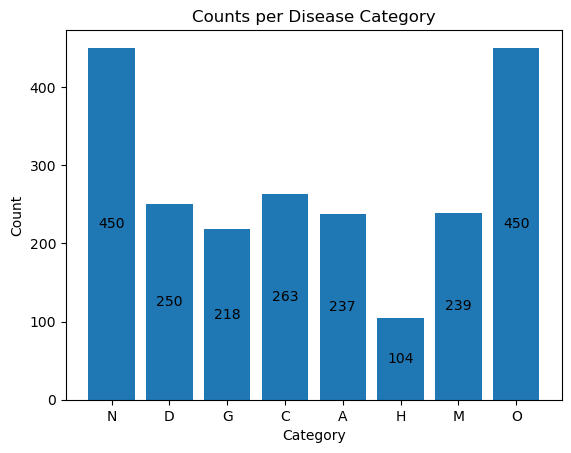

In [7]:
plt.bar_label(plt.bar(X, y), label_type="center")
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Counts per Disease Category")

In [8]:
# Creating the target Labels 
def createTarget(df):
    df['Labels'] = [[0,0,0,0,0,0,0] for i in range (0,len(df))] #create a column for labels with 8 0s
    target_columns = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    label = [] #create empty label array
    for i in range(0, len(df)):
        for target in target_columns:
            label.append(df.loc[i, target]) #append the value for the column for each row to the label
        
        df.at[i,'Labels'] = label #update the label column with the label array
        label = [] #reset label array
            

In [9]:
createTarget(shuffled_df)

In [10]:
shuffled_df = shuffled_df.drop(['Patient ID', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'], axis=1)
shuffled_df

,Patient Age,Patient Sex,Filename,Diagnosis,Labels
0,65,Female,781_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]"
1,60,Female,1080_left.jpg,macular epiretinal membrane,"[0, 0, 0, 0, 0, 0, 0, 1]"
2,57,Female,1579_left.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]"
3,66,Male,276_left.jpg,macular coloboma,"[0, 0, 0, 0, 0, 0, 0, 1]"
4,61,Male,158_right.jpg,dry age-related macular degeneration,"[0, 0, 0, 0, 1, 0, 0, 0]"
...,...,...,...,...,...
2206,53,Male,327_left.jpg,moderate non proliferative retinopathy,"[0, 1, 0, 0, 0, 0, 0, 0]"
2207,50,Female,1629_right.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]"
2208,55,Female,2335_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]"
2209,50,Female,1404_left.jpg,suspected glaucoma,"[0, 0, 1, 0, 0, 0, 0, 0]"


In [11]:
def binary_to_decimal(binary_list):
    """
    Converts a list of 0s and 1s (binary) to its decimal equivalent.

    :param binary_list: List of 0s and 1s.
    :return: Decimal equivalent of the binary number.
    """
    return sum(val * (2 ** idx) for idx, val in enumerate(reversed(binary_list)))

In [12]:
# Apply the function to each row
shuffled_df['target'] = shuffled_df['Labels'].apply(binary_to_decimal)
shuffled_df

,Patient Age,Patient Sex,Filename,Diagnosis,Labels,target
0,65,Female,781_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]",128
1,60,Female,1080_left.jpg,macular epiretinal membrane,"[0, 0, 0, 0, 0, 0, 0, 1]",1
2,57,Female,1579_left.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]",2
3,66,Male,276_left.jpg,macular coloboma,"[0, 0, 0, 0, 0, 0, 0, 1]",1
4,61,Male,158_right.jpg,dry age-related macular degeneration,"[0, 0, 0, 0, 1, 0, 0, 0]",8
...,...,...,...,...,...,...
2206,53,Male,327_left.jpg,moderate non proliferative retinopathy,"[0, 1, 0, 0, 0, 0, 0, 0]",64
2207,50,Female,1629_right.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]",2
2208,55,Female,2335_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]",128
2209,50,Female,1404_left.jpg,suspected glaucoma,"[0, 0, 1, 0, 0, 0, 0, 0]",32


In [13]:
# Path to your image dataset
image_dataset_path = "./ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training images"
validation_path = "./ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Testing images"

In [14]:
shuffled_df["filepath"] = shuffled_df['Filename'].apply(lambda x: os.path.join(image_dataset_path, x))

In [15]:
import cv2
import numpy as np

# Function to preprocess images
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (128, 128))  # Resize to the desired input size for your CNN
    return image

# Applying the function to each image path
shuffled_df['image'] = shuffled_df['filepath'].apply(preprocess_image)

# Normalize age and encode gender
shuffled_df['Patient Age'] = shuffled_df['Patient Age'] / 100  # Assuming age is less than 100
shuffled_df['Patient Sex'] = shuffled_df['Patient Sex'].map({'Male': 0, 'Female': 1})  # Binary encoding

In [16]:
shuffled_df

,Patient Age,Patient Sex,Filename,Diagnosis,Labels,target,filepath,image
0,0.65,1,781_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]",128,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
1,0.60,1,1080_left.jpg,macular epiretinal membrane,"[0, 0, 0, 0, 0, 0, 0, 1]",1,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2,0.57,1,1579_left.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]",2,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
3,0.66,0,276_left.jpg,macular coloboma,"[0, 0, 0, 0, 0, 0, 0, 1]",1,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
4,0.61,0,158_right.jpg,dry age-related macular degeneration,"[0, 0, 0, 0, 1, 0, 0, 0]",8,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
...,...,...,...,...,...,...,...,...
2206,0.53,0,327_left.jpg,moderate non proliferative retinopathy,"[0, 1, 0, 0, 0, 0, 0, 0]",64,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2207,0.50,1,1629_right.jpg,pathological myopia,"[0, 0, 0, 0, 0, 0, 1, 0]",2,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2208,0.55,1,2335_left.jpg,normal fundus,"[1, 0, 0, 0, 0, 0, 0, 0]",128,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2209,0.50,1,1404_left.jpg,suspected glaucoma,"[0, 0, 1, 0, 0, 0, 0, 0]",32,./ocular-disease-recognition-odir5k/ODIR-5K/OD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np


# Example DataFrame
# df = pd.DataFrame({'age': [25, 30, 45], 'gender': ['male', 'female', 'male']})

# Scale age
scaler = StandardScaler()
ages_scaled = scaler.fit_transform(shuffled_df[['Patient Age']])

# Encode gender
encoder = OneHotEncoder()
genders_encoded = encoder.fit_transform(shuffled_df[['Patient Sex']]).toarray()

# Combine age and gender
age_gender_combined = np.hstack((ages_scaled, genders_encoded))

# Now, age_gender_combined is what you will use as train_age_gender in model training


In [18]:
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.applications.vgg19 import VGG19

# vgg = VGG19(weights="imagenet",include_top = False,input_shape=(128,128,3))
# # Assuming image_matrix is a 4D tensor: [samples, height, width, channels]
# # age and gender are 1D tensors

# def create_model():
#     # Image input branch - CNN
# #     image_input = layers.Input(shape=(128, 128, 3))
    
#     image_input = layers.Input(shape=(128, 128, 3))
#     x = vgg(image_input)
#     x = layers.Flatten()(x)
#     image_branch = models.Model(inputs=image_input, outputs=x)

# #     x = layers.Conv2D(32, (3, 3), activation='relu')(image_input)
# #     x = layers.MaxPooling2D((2, 2))(x)
# #     x = layers.Flatten()(x)
# #     image_branch = models.Model(inputs=image_input, outputs=x)

#     # Age and gender input branch
#     age_gender_input = layers.Input(shape=(3,))  # Assuming age and gender are scaled/encoded
#     y = layers.Dense(32, activation='relu')(age_gender_input)
#     age_gender_branch = models.Model(inputs=age_gender_input, outputs=y)

#     # Concatenate branches
#     combined = layers.concatenate([image_branch.output, age_gender_branch.output])

#     # Dense layers and output
#     z = layers.Dense(64, activation='relu')(combined)
#     z = layers.Dense(8, activation='sigmoid')(z)  # num_diseases = length of label list

#     model = models.Model(inputs=[image_branch.input, age_gender_branch.input], outputs=z)

#     return model


# model = create_model()
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])




# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.applications.vgg19 import VGG19

# # Load the VGG19 model pre-trained on ImageNet data
# vgg = VGG19(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# def create_model():
#     # Image input branch - CNN
#     image_input = layers.Input(shape=(128, 128, 3))
#     x = vgg(image_input)  # Pass the input through the VGG19 model
#     x = layers.Flatten()(x)  # Flatten the output of VGG19
#     image_branch = models.Model(inputs=image_input, outputs=x)

#     # Dense layers and output
#     z = layers.Dense(64, activation='relu')(image_branch.output)
#     z = layers.Dense(8, activation='sigmoid')(z)  # num_diseases = length of label list

#     # Create the model with only image input
#     model = models.Model(inputs=image_input, outputs=z)

#     return model

# # Create and compile the model
# model = create_model()
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.applications.vgg19 import VGG19

# vgg = VGG19(weights="imagenet",include_top = False,input_shape=(128,128,3))
# # Assuming image_matrix is a 4D tensor: [samples, height, width, channels]
# # age and gender are 1D tensors

# def create_model():
#     # Image input branch - CNN
# #     image_input = layers.Input(shape=(128, 128, 3))
    
#     image_input = layers.Input(shape=(128, 128, 3))
#     x = vgg(image_input)
#     x = layers.Flatten()(x)
#     image_branch = models.Model(inputs=image_input, outputs=x)

# #     x = layers.Conv2D(32, (3, 3), activation='relu')(image_input)
# #     x = layers.MaxPooling2D((2, 2))(x)
# #     x = layers.Flatten()(x)
# #     image_branch = models.Model(inputs=image_input, outputs=x)

#     # Age and gender input branch
#     age_gender_input = layers.Input(shape=(3,))  # Assuming age and gender are scaled/encoded
#     y = layers.Dense(32, activation='relu')(age_gender_input)
#     age_gender_branch = models.Model(inputs=age_gender_input, outputs=y)

#     # Concatenate branches
#     combined = layers.concatenate([image_branch.output, age_gender_branch.output])

#     # Dense layers and output
#     z = layers.Dense(64, activation='relu')(combined)
#     z = layers.Dense(8, activation='sigmoid')(z)  # num_diseases = length of label list

#     model = models.Model(inputs=[image_branch.input, age_gender_branch.input], outputs=z)

#     return model


# # model = create_model()
# # model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # from tensorflow.keras.applications.vgg19 import VGG19
# import tensorflow as tf
# # vgg = VGG19(weights="imagenet",include_top = False,input_shape=(128,128,3))

# # for layer in vgg.layers:
# #     layer.trainable = False

# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Input
# # image_input = Input(shape=(128, 128, 3))
# model = Sequential()

# model.add(Flatten())
# model.add(Dense(256,activation = "relu"))
# model.add(tf.keras.layers.BatchNormalization())
# model.add(Dense(256,activation = "relu"))
# model.add(tf.keras.layers.BatchNormalization())
# model.add(Dense(8,activation="softmax"))



In [19]:
# num_classes = 8

# import tensorflow as tf
# from tensorflow.keras.applications.resnet50 import ResNet50
# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D

# # Load pre-trained ResNet50 model without the top layer
# base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# # Freeze the layers of the base model
# for layer in base_model.layers:
#     layer.trainable = False

# # Create a Sequential model and add the base model
# model = Sequential()
# model.add(base_model)

# # Add global average pooling to reduce number of parameters
# model.add(GlobalAveragePooling2D())

# # Add fully connected layers
# model.add(Dense(1024, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.5))

# # Output layer for classification (adjust the number of units as per the number of classes)
# model.add(Dense(number_of_classes, activation='softmax'))

# # Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Model summary
# model.summary()



num_classes = 8

# import tensorflow as tf
# # from tensorflow.keras.applications.resnet50 import ResNet50
# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D

# # Load pre-trained ResNet50 model without the top layer
# # base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# # Freeze the layers of the base model
# # for layer in base_model.layers:
# #     layer.trainable = False

# # Create a Sequential model and add the base model
# model = Sequential()
# # model.add(base_model)

# # Add global average pooling to reduce number of parameters
# model.add(GlobalAveragePooling2D())

# # Add fully connected layers
# model.add(Dense(1024, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.5))

# # Output layer for classification (adjust the number of units as per the number of classes)
# model.add(Dense(num_classes, activation='softmax'))

# # Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Model summary
# model.summary()





num_classes = 8
img_height = 128
img_width = 128
# model = Sequential([
#   layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
#   layers.Conv2D(16, 3, padding='same', activation='relu'),
#   layers.MaxPooling2D(),
#   layers.Conv2D(32, 3, padding='same', activation='relu'),
#   layers.MaxPooling2D(),
#   layers.Conv2D(64, 3, padding='same', activation='relu'),
#   layers.MaxPooling2D(),
#   layers.Flatten(),
#   layers.Dense(128, activation='relu'),
#   layers.Dense(num_classes)
# ])

model = Sequential([
    # Rescaling layer (normalizing the pixel values)
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Block
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),  # Dropout layer for regularization

    # Second Convolution Block
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),  # Another Dropout layer

    # Third Convolution Block
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),  # Increasing dropout rate

    # Fourth Convolution Block
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),  # Consistent dropout rate

    # Flattening the output for the Dense layers
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(256, activation='relu'),  # Increased the number of neurons
    layers.Dropout(0.4),  # Higher dropout rate for the dense layer

    # Output Layer (assuming num_classes is the number of classes)
    layers.Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])






# Model summary to inspect the architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 16)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 64, 64, 16)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                    

In [20]:
# model.build(input_shape=(None, 128, 128, 3))
# model.summary()

In [21]:
image_data = np.array(shuffled_df["image"].tolist())

labels = shuffled_df["target"]

In [22]:
len(labels)

2211

In [23]:
len(image_data)

2211

In [24]:
len(labels.unique())

8

In [25]:
# train_images, val_images, train_age_gender, val_age_gender, train_labels, val_labels = train_test_split(
#     image_data, age_gender_combined, labels, test_size=0.2, random_state=42)

train_images, val_images, train_labels, val_labels = train_test_split(
    image_data, labels, test_size=0.2, random_state=42)

print(len(train_images))
print(len(val_images))
print(len(train_labels))
print(len(val_labels))

1768
443
1768
443


In [26]:
# train_labels = np.array(train_labels.tolist())
# val_labels = np.array(val_labels.tolist())

#model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
# Training - assuming you have prepared `train_data`, `train_labels`, `val_data`, `val_labels`
# model.fit([train_images, train_age_gender], train_labels, validation_data=([val_images, val_age_gender], val_labels), epochs=10, batch_size=32)

#model.fit(train_images, train_labels, validation_data=(val_images, val_labels), epochs=10, batch_size=32)

# Assuming train_labels and val_labels are your label arrays
# and num_classes is the number of classes (39 in this case)
from tensorflow.keras.utils import to_categorical

num_classes = 8  # Update this if the number of classes is different
label_encoder = LabelEncoder()
print(len(train_labels))
train_labels = label_encoder.fit_transform(train_labels)
train_labels_one_hot = to_categorical(train_labels, num_classes)

val_labels = label_encoder.fit_transform(val_labels)
val_labels_one_hot = to_categorical(val_labels, num_classes)

len(train_labels)
len(train_images)

1768


1768

In [27]:
# # Set the learning rate
# learning_rate = 0.1  # You can modify this value as needed

# # Configure the optimizer with the specified learning rate
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)


model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [32]:

model.fit(train_images, train_labels_one_hot, validation_data=(val_images, val_labels_one_hot), epochs=35, batch_size=16)


Epoch 1/35
111/111 [==============================] - 25s 226ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 2/35
111/111 [==============================] - 25s 226ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 3/35
111/111 [==============================] - 25s 228ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 4/35
111/111 [==============================] - 25s 226ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 5/35
111/111 [==============================] - 25s 225ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 6/35
111/111 [==============================] - 25s 227ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 7/35
111/111 [==============================] - 25s 225ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_ac

In [29]:
num_classes = 8

model = Sequential([
  layers.Rescaling(1./255, input_shape=(128, 128, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


In [30]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [31]:

model.fit(train_images, train_labels_one_hot, validation_data=(val_images, val_labels_one_hot), epochs=15, batch_size=16)


Epoch 1/15
111/111 [==============================] - 26s 227ms/step - loss: 8.0352 - accuracy: 0.1267 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 2/15
111/111 [==============================] - 25s 224ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 3/15
111/111 [==============================] - 25s 228ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 4/15
111/111 [==============================] - 25s 224ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 5/15
111/111 [==============================] - 25s 223ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 6/15
111/111 [==============================] - 25s 226ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_accuracy: 0.0948
Epoch 7/15
111/111 [==============================] - 26s 234ms/step - loss: 9.0254 - accuracy: 0.1103 - val_loss: 9.2051 - val_ac